# Reward Model Debug Notebook

**Prerequisito**: eseguire un training christiano con la nuova pipeline.
Questo notebook carica `reward_model.pt` e `debug_data.pkl` dall'output dir
e produce tutti i grafici diagnostici senza richiedere SUMO o l'environment.

In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import torch
import torch.nn as nn

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120


In [3]:
# ── Config: punta al tuo run ──────────────────────────────────────────────
# Cambia questo path con la directory del run che vuoi analizzare
RUN_DIR = Path("../outputs/train/2026-05-09_23-58-21_PPO_seg_1_reg_ON")

REWARD_MODEL_PATH = RUN_DIR / "reward_model.pt"
DEBUG_DATA_PATH   = RUN_DIR / "debug_data.pkl"


In [4]:
# ── 1. Reward model — ricostruzione standalone ────────────────────────────
# Replica esatta di SimpleRewardNet: nessun import da sumo-rl-ego necessario.

class _SimpleRewardNet(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden_size: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_size), nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),        nn.Tanh(),
            nn.Linear(hidden_size, 1, bias=False),
        )

    def forward(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([obs, act], dim=1)).squeeze(-1)


def load_reward_ensemble(path):
    """
    Ricostruisce il RewardEnsemble da checkpoint.
    Ritorna (members: list[_SimpleRewardNet], ckpt: dict).
    """
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    obs_dim, act_dim, hidden = ckpt["obs_dim"], ckpt["act_dim"], ckpt["hidden_size"]
    n = ckpt["n_members"]
    sd = ckpt["state_dict"]

    members = []
    for i in range(n):
        m = _SimpleRewardNet(obs_dim, act_dim, hidden)
        member_sd = {
            k[len(f"members.{i}."):]: v
            for k, v in sd.items()
            if k.startswith(f"members.{i}.")
        }
        m.load_state_dict(member_sd)
        m.eval()
        members.append(m)

    return members, ckpt


members, ckpt = load_reward_ensemble(REWARD_MODEL_PATH)
print(
    f"Caricato ensemble: {ckpt['n_members']} membri  |  "
    f"obs_dim={ckpt['obs_dim']}  act_dim={ckpt['act_dim']}  hidden={ckpt['hidden_size']}"
)


# Helpers di inferenza standalone
@torch.no_grad()
def predict_mean_std(obs: np.ndarray, acts: np.ndarray):
    """Ritorna (mean, std) su (T,) per ogni timestep."""
    obs_t  = torch.tensor(obs,  dtype=torch.float32)
    acts_t = torch.tensor(acts, dtype=torch.float32)
    preds  = np.stack([m(obs_t, acts_t).numpy() for m in members], axis=0)  # (n, T)
    return preds.mean(axis=0), preds.std(axis=0)


Caricato ensemble: 3 membri  |  obs_dim=16  act_dim=2  hidden=256


In [5]:
# ── 2. Caricamento debug data ──────────────────────────────────────────────
with open(DEBUG_DATA_PATH, "rb") as f:
    data = pickle.load(f)

trajs                = data["trajectories"]
ep_true_returns      = np.array(data["episode_true_returns"])
ep_pred_returns      = np.array(data["episode_pred_returns"])

# Flatten step-level arrays for population-level analyses
all_true  = np.concatenate([t["true_rewards"]      for t in trajs])
all_pred  = np.concatenate([t["pred_rewards_mean"] for t in trajs])
all_std   = np.concatenate([t["pred_rewards_std"]  for t in trajs])
all_err   = all_pred - all_true   # signed error
all_abserr = np.abs(all_err)

ep_gap = ep_pred_returns - ep_true_returns

# Statistiche riassuntive
p_ep, _   = pearsonr(ep_true_returns, ep_pred_returns)
s_ep, _   = spearmanr(ep_true_returns, ep_pred_returns)
p_step, _ = pearsonr(all_true, all_pred)

print(f"\nEpisodi: {len(trajs)} | Step totali: {len(all_true)}")
print(f"True return:  mean={ep_true_returns.mean():.2f}  std={ep_true_returns.std():.2f}")
print(f"Pred return:  mean={ep_pred_returns.mean():.2f}  std={ep_pred_returns.std():.2f}")
print(f"Reward gap:   mean={ep_gap.mean():.2f}  (positivo = RM ottimista)")
print(f"Pearson r  (episode):  {p_ep:.3f}")
print(f"Spearman ρ (episode):  {s_ep:.3f}")
print(f"Pearson r  (step):     {p_step:.3f}")
print(f"Step MAE:              {all_abserr.mean():.4f}")
print(f"Step RMSE:             {np.sqrt((all_err**2).mean()):.4f}")



Episodi: 17 | Step totali: 2495
True return:  mean=28.23  std=15.98
Pred return:  mean=303.16  std=114.62
Reward gap:   mean=274.93  (positivo = RM ottimista)
Pearson r  (episode):  0.969
Spearman ρ (episode):  0.961
Pearson r  (step):     0.321
Step MAE:              1.8898
Step RMSE:             2.2459


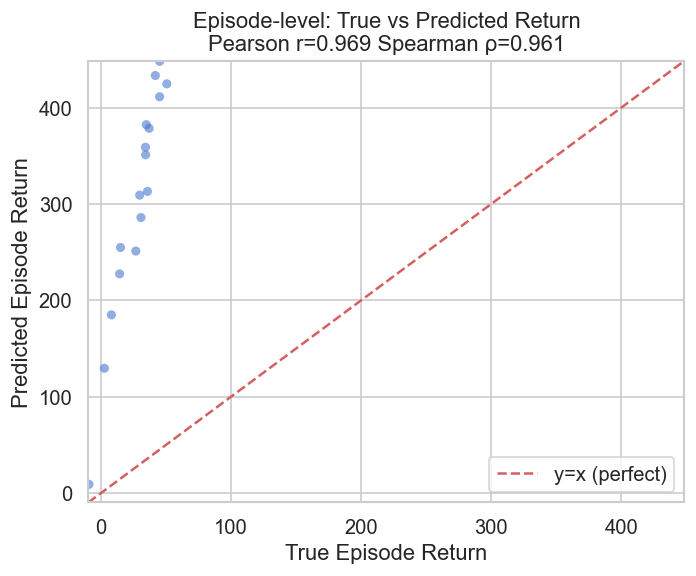

In [6]:
# ── 3. Episode-level scatter: true vs predicted return ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ep_true_returns, ep_pred_returns, alpha=0.6, s=30, edgecolors="none")

lim = (min(ep_true_returns.min(), ep_pred_returns.min()) - 0.5,
max(ep_true_returns.max(), ep_pred_returns.max()) + 0.5)
ax.plot(lim, lim, "r--", lw=1.5, label="y=x (perfect)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("True Episode Return"); ax.set_ylabel("Predicted Episode Return")
ax.set_title(f"Episode-level: True vs Predicted Return\nPearson r={p_ep:.3f} Spearman ρ={s_ep:.3f}")
ax.legend()
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_scatter_episode.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Sano : punti vicini alla diagonale, r > 0.85
# Hacking: cluster in alto a sinistra (pred alta, true bassa) → RM sovrastima
# su traiettorie che la policy ha imparato a sfruttare

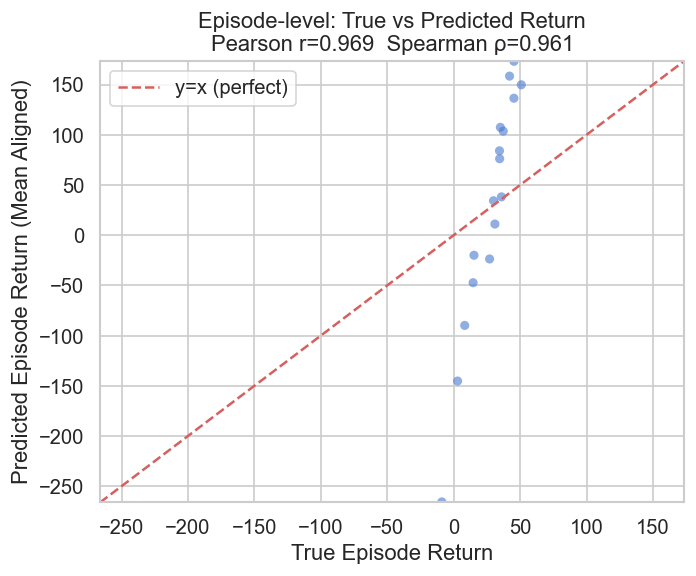

In [7]:
# ── Allineamento delle medie (Rimozione del Bias invariante) ──
# Calcoliamo il bias costante
bias = ep_pred_returns.mean() - ep_true_returns.mean()

# Trasliamo le predizioni affinché abbiano la stessa media dei true returns
ep_pred_aligned = ep_pred_returns - bias

# ── 3. Episode-level scatter: true vs predicted return ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
# Usiamo i dati allineati qui!
ax.scatter(ep_true_returns, ep_pred_aligned, alpha=0.6, s=30, edgecolors="none")

lim = (min(ep_true_returns.min(), ep_pred_aligned.min()) - 0.5,
       max(ep_true_returns.max(), ep_pred_aligned.max()) + 0.5)
ax.plot(lim, lim, "r--", lw=1.5, label="y=x (perfect)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("True Episode Return"); ax.set_ylabel("Predicted Episode Return (Mean Aligned)")
ax.set_title(f"Episode-level: True vs Predicted Return\nPearson r={p_ep:.3f}  Spearman ρ={s_ep:.3f}")
ax.legend()
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_scatter_episode.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Sano   : punti vicini alla diagonale, r > 0.85
# Hacking: cluster in alto a sinistra (pred alta, true bassa) → RM sovrastima
#          su traiettorie che la policy ha imparato a sfruttare


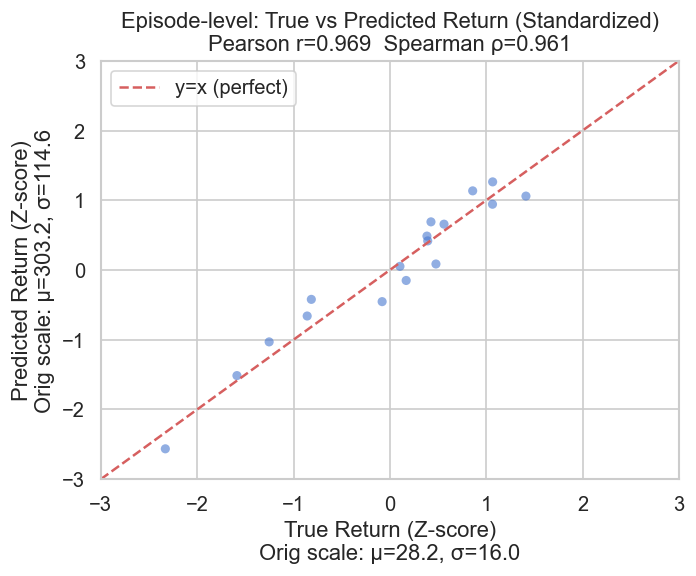

In [8]:
# ── Standardizzazione (Z-score) ──
# Calcolo medie e deviazioni standard
true_mean, true_std = ep_true_returns.mean(), ep_true_returns.std() + 1e-8
pred_mean, pred_std = ep_pred_returns.mean(), ep_pred_returns.std() + 1e-8

# Standardizzazione
ep_true_z = (ep_true_returns - true_mean) / true_std
ep_pred_z = (ep_pred_returns - pred_mean) / pred_std

# ── 3. Episode-level scatter (Standardizzato) ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(ep_true_z, ep_pred_z, alpha=0.6, s=30, edgecolors="none")

# Ora i limiti possono essere fissi, di solito tra -3 e +3 (regola del 3 sigma)
lim = (-3, 3)
ax.plot(lim, lim, "r--", lw=1.5, label="y=x (perfect)")
ax.set_xlim(lim); ax.set_ylim(lim)

# Indichiamo chiaramente sugli assi che i dati sono standardizzati
ax.set_xlabel(f"True Return (Z-score)\nOrig scale: μ={true_mean:.1f}, σ={true_std:.1f}")
ax.set_ylabel(f"Predicted Return (Z-score)\nOrig scale: μ={pred_mean:.1f}, σ={pred_std:.1f}")

ax.set_title(f"Episode-level: True vs Predicted Return (Standardized)\nPearson r={p_ep:.3f}  Spearman ρ={s_ep:.3f}")
ax.legend()
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_scatter_episode_z.png", dpi=150); plt.show()

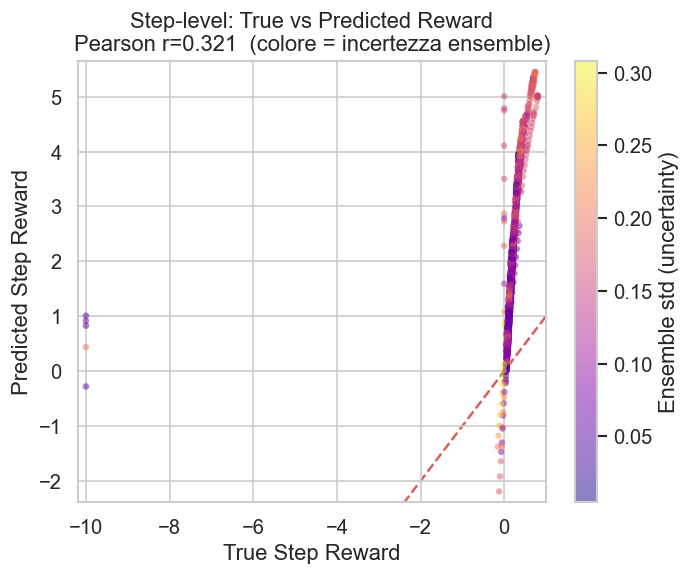

In [9]:
# ── 4. Step-level scatter: true vs predicted reward ───────────────────────
# Campiona max 5000 step per leggibilità
idx = np.random.choice(len(all_true), size=min(5000, len(all_true)), replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(all_true[idx], all_pred[idx], c=all_std[idx],
                cmap="plasma", alpha=0.5, s=15, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Ensemble std (uncertainty)")

# 1. Calcola i limiti separatamente per X (True) e Y (Pred)
xlim = (all_true.min() - 0.2, all_true.max() + 0.2)
ylim = (all_pred.min() - 0.2, all_pred.max() + 0.2)

# 2. Imposta i limiti indipendenti per i due assi
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# 3. Disegna la linea y=x usando i minimi e massimi assoluti
# matplotlib la taglierà automaticamente dove esce dai limiti degli assi che abbiamo appena impostato
global_min = min(xlim[0], ylim[0])
global_max = max(xlim[1], ylim[1])
ax.plot([global_min, global_max], [global_min, global_max], "r--", lw=1.5, zorder=0)

ax.set_xlabel("True Step Reward"); ax.set_ylabel("Predicted Step Reward")
ax.set_title(f"Step-level: True vs Predicted Reward\nPearson r={p_step:.3f}  (colore = incertezza ensemble)")
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_scatter_step.png", dpi=150); plt.show()

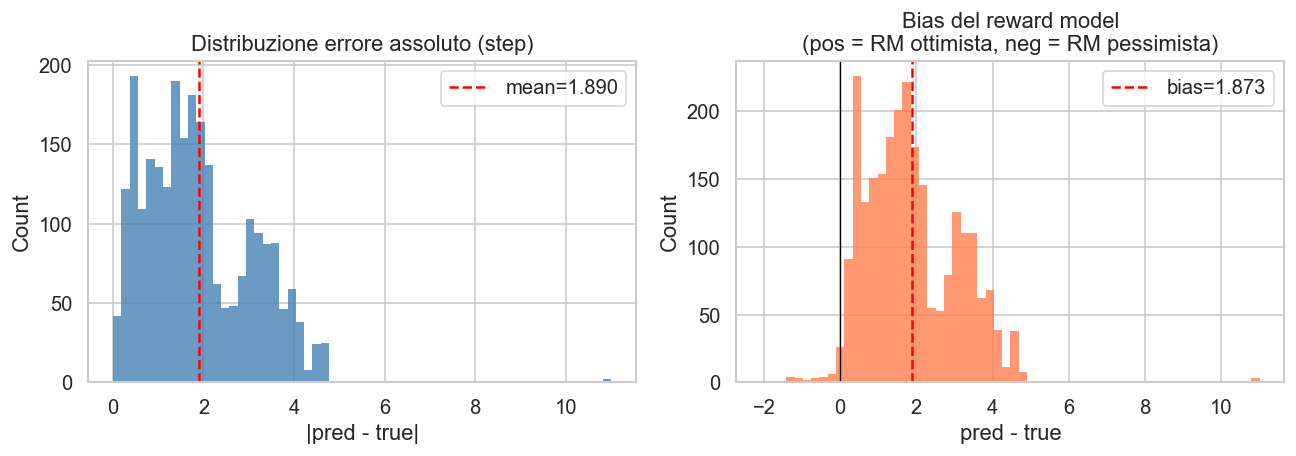

In [10]:
# ── 5. Distribuzione dell'errore step-level ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Istogramma dell'errore assoluto
axes[0].hist(all_abserr, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(all_abserr.mean(), color="red", ls="--", label=f"mean={all_abserr.mean():.3f}")
axes[0].set_xlabel("|pred - true|"); axes[0].set_ylabel("Count")
axes[0].set_title("Distribuzione errore assoluto (step)"); axes[0].legend()

# Istogramma dell'errore signed (bias del RM)
axes[1].hist(all_err, bins=60, color="coral", edgecolor="none", alpha=0.8)
axes[1].axvline(0, color="black", ls="-", lw=0.8)
axes[1].axvline(all_err.mean(), color="red", ls="--", label=f"bias={all_err.mean():.3f}")
axes[1].set_xlabel("pred - true"); axes[1].set_ylabel("Count")
axes[1].set_title("Bias del reward model\n(pos = RM ottimista, neg = RM pessimista)"); axes[1].legend()

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_error_dist.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Media bias > 0 → il RM sistematicamente sovrastima → condizione necessaria per reward hacking
# Distribuzione asimmetrica con coda destra → outlier in cui il RM è molto ottimista


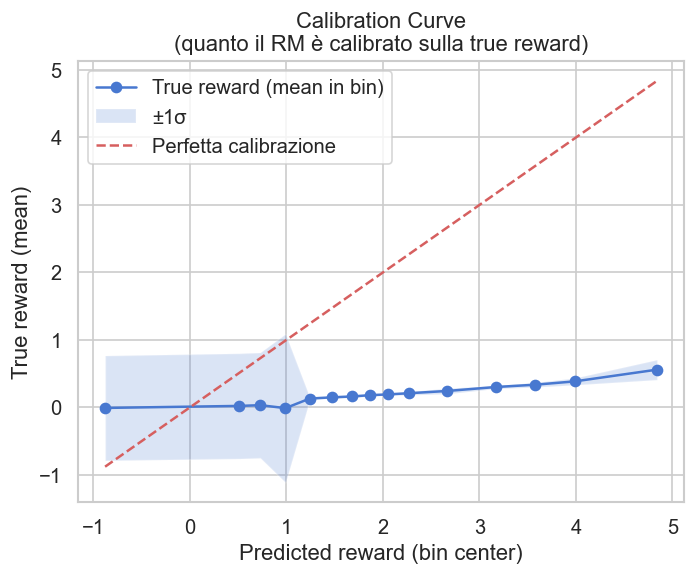

In [11]:
# ── 6. Calibration curve (binned) ─────────────────────────────────────────
N_BINS = 15
bins = np.percentile(all_pred, np.linspace(0, 100, N_BINS + 1))
bin_centers, bin_true_means, bin_true_stds = [], [], []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (all_pred >= lo) & (all_pred < hi)
    if mask.sum() < 5:
        continue
    bin_centers.append((lo + hi) / 2)
    bin_true_means.append(all_true[mask].mean())
    bin_true_stds.append(all_true[mask].std())

bin_centers  = np.array(bin_centers)
bin_true_means = np.array(bin_true_means)
bin_true_stds  = np.array(bin_true_stds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(bin_centers, bin_true_means, "o-", label="True reward (mean in bin)")
ax.fill_between(bin_centers,
                bin_true_means - bin_true_stds,
                bin_true_means + bin_true_stds,
                alpha=0.2, label="±1σ")
diag_min = min(bin_centers.min(), bin_true_means.min())
diag_max = max(bin_centers.max(), bin_true_means.max())
ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", lw=1.5, label="Perfetta calibrazione")
ax.set_xlabel("Predicted reward (bin center)"); ax.set_ylabel("True reward (mean)")
ax.set_title("Calibration Curve\n(quanto il RM è calibrato sulla true reward)")
ax.legend()
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_calibration.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curva vicina alla diagonale → RM ben calibrato
# Curva "S" → under-confident al centro, overconfident agli estremi
# Curva piatta → il RM non discrimina tra buone e cattive traiettorie


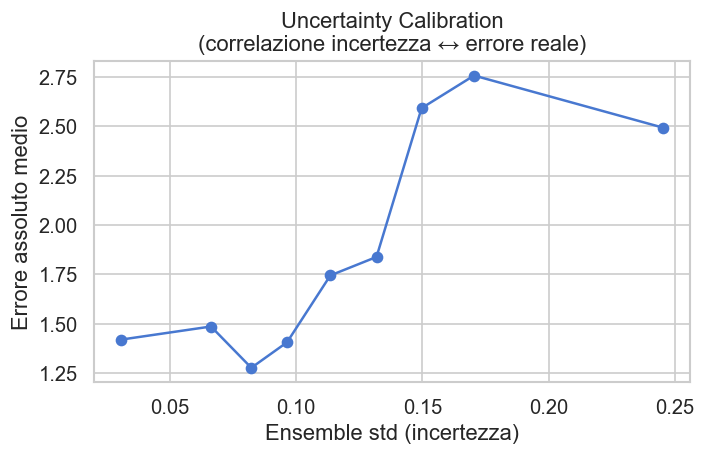

In [13]:
# ── 7. Uncertainty vs errore assoluto ─────────────────────────────────────
# Testa se l'incertezza ensemble è predittiva dell'errore (uncertainty calibration)
fig, ax = plt.subplots(figsize=(6, 4))

std_bins  = np.percentile(all_std, np.linspace(0, 100, 10))
unc_means = [all_abserr[(all_std >= lo) & (all_std < hi)].mean()
             for lo, hi in zip(std_bins[:-1], std_bins[1:])]
unc_ctrs  = [(lo + hi) / 2 for lo, hi in zip(std_bins[:-1], std_bins[1:])]

ax.plot(unc_ctrs, unc_means, "o-")
ax.set_xlabel("Ensemble std (incertezza)"); ax.set_ylabel("Errore assoluto medio")
ax.set_title("Uncertainty Calibration\n(correlazione incertezza ↔ errore reale)")
plt.tight_layout(); plt.savefig(RUN_DIR / "plot_uncertainty_calibration.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curva crescente → uncertainty predittiva dell'errore → ensemble utile come misura di OOD
# Curva piatta → ensemble non è informativo sull'errore → false confidence generale


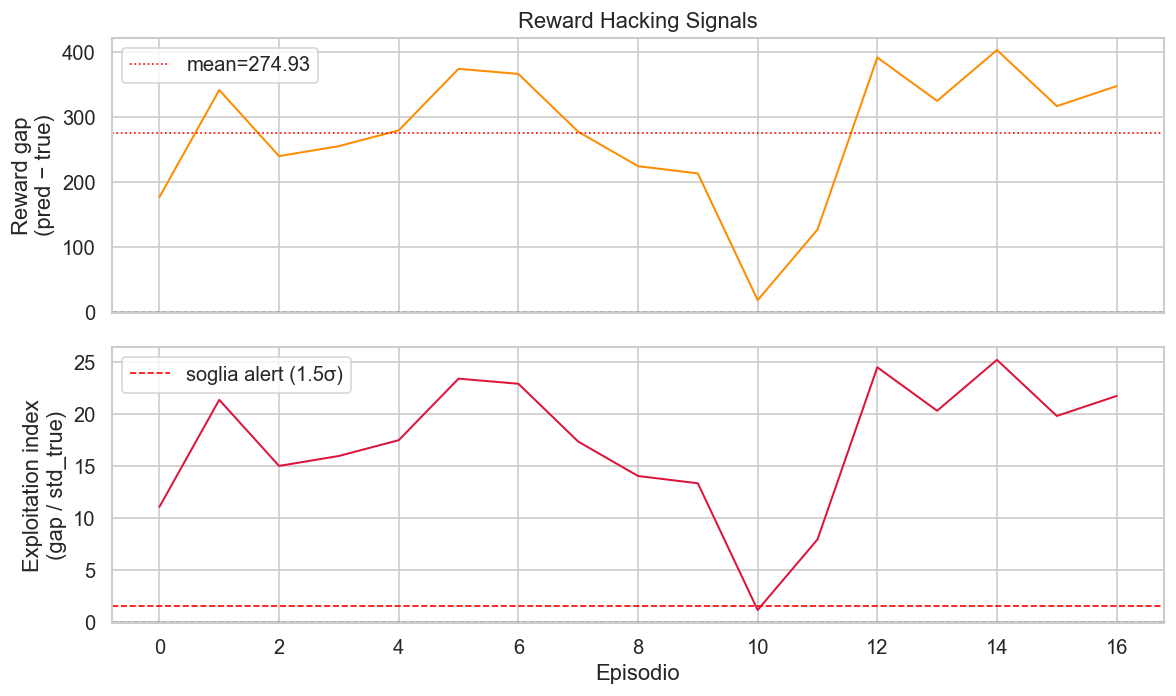

In [14]:
# ── 8. Reward gap over episodes (hacking signal) ──────────────────────────
exploitation_index = ep_gap / (ep_true_returns.std() + 1e-8)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(ep_gap, lw=1.2, color="darkorange")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].axhline(ep_gap.mean(), color="red", lw=1, ls=":", label=f"mean={ep_gap.mean():.2f}")
axes[0].set_ylabel("Reward gap\n(pred − true)"); axes[0].set_title("Reward Hacking Signals"); axes[0].legend()

axes[1].plot(exploitation_index, lw=1.2, color="crimson")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].axhline(1.5, color="red", lw=1, ls="--", label="soglia alert (1.5σ)")
axes[1].set_xlabel("Episodio"); axes[1].set_ylabel("Exploitation index\n(gap / std_true)")
axes[1].legend()

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_hacking.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Gap sistematicamente > 0 → il RM sovrastima → condizione per reward hacking
# Exploitation index > 1.5 → segnale forte di hacking (gap > 1.5 std del true reward)
# Trend crescente → la policy sta imparando a sfruttare il RM nel tempo


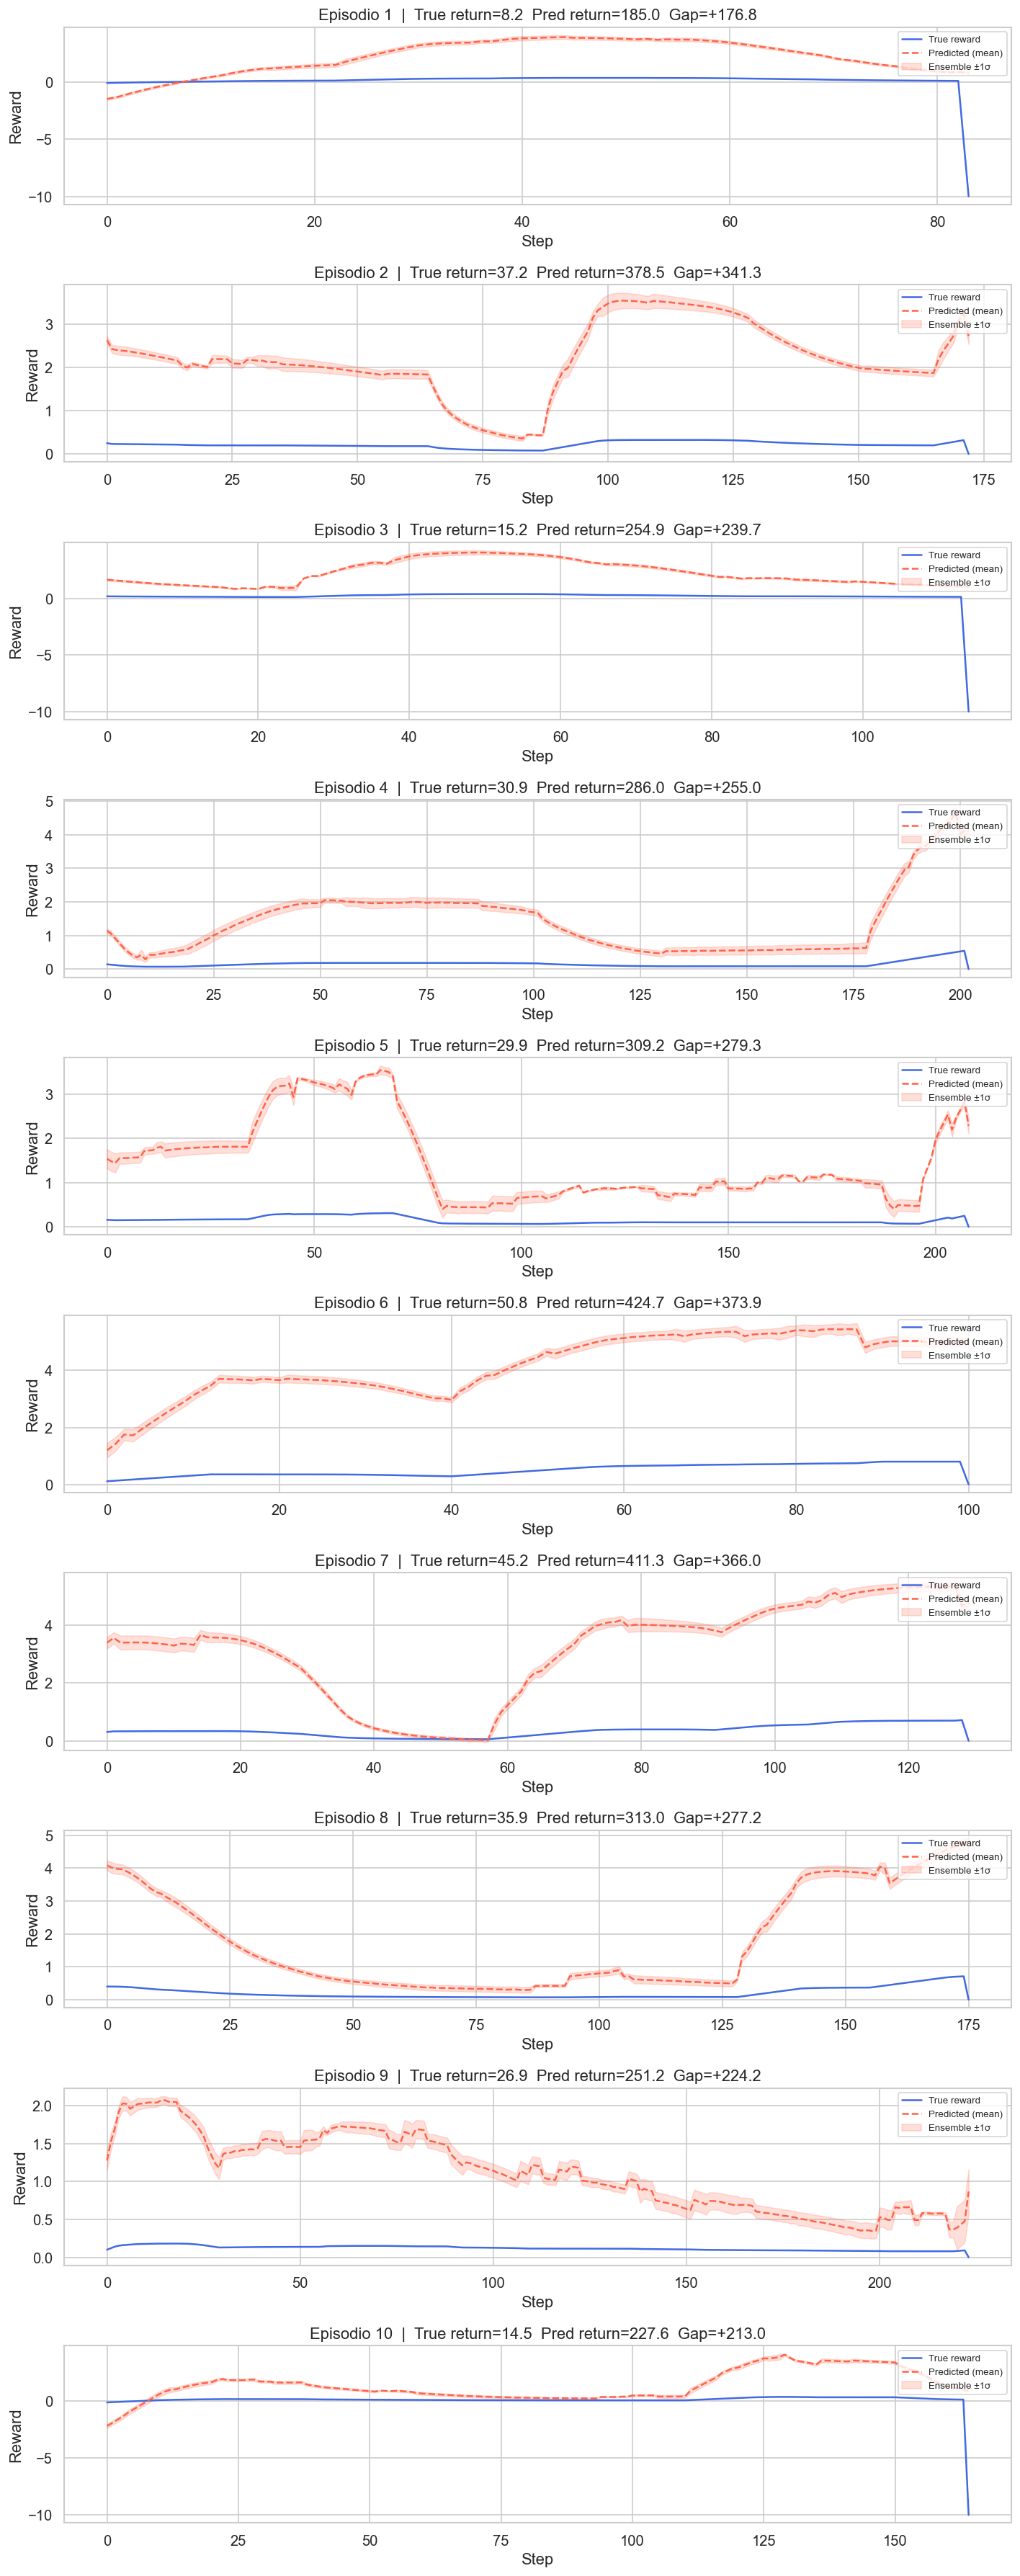

In [15]:
# ── 9. Reward curve per traiettoria (true vs pred) ────────────────────────
# Visualizza le prime 4 traiettorie
N_SHOW = min(10, len(trajs))

fig, axes = plt.subplots(N_SHOW, 1, figsize=(12, 3 * N_SHOW), sharex=False)
if N_SHOW == 1:
    axes = [axes]

for i, (traj, ax) in enumerate(zip(trajs[:N_SHOW], axes)):
    t = np.arange(len(traj["true_rewards"]))
    ax.plot(t, traj["true_rewards"],      label="True reward",      color="royalblue", lw=1.5)
    ax.plot(t, traj["pred_rewards_mean"], label="Predicted (mean)", color="tomato",    lw=1.5, ls="--")
    ax.fill_between(t,
                    traj["pred_rewards_mean"] - traj["pred_rewards_std"],
                    traj["pred_rewards_mean"] + traj["pred_rewards_std"],
                    alpha=0.2, color="tomato", label="Ensemble ±1σ")
    tr  = traj["true_rewards"].sum()
    pr  = traj["pred_rewards_mean"].sum()
    ax.set_title(f"Episodio {i+1}  |  True return={tr:.1f}  Pred return={pr:.1f}  Gap={pr-tr:+.1f}")
    ax.set_xlabel("Step"); ax.set_ylabel("Reward")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_trajectories.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Curve allineate → RM impara la forma temporale della reward
# RM "liscio" mentre true è rumoroso → RM media bene il segnale
# RM sistematicamente più alto → bias ottimistico → segnale di hacking


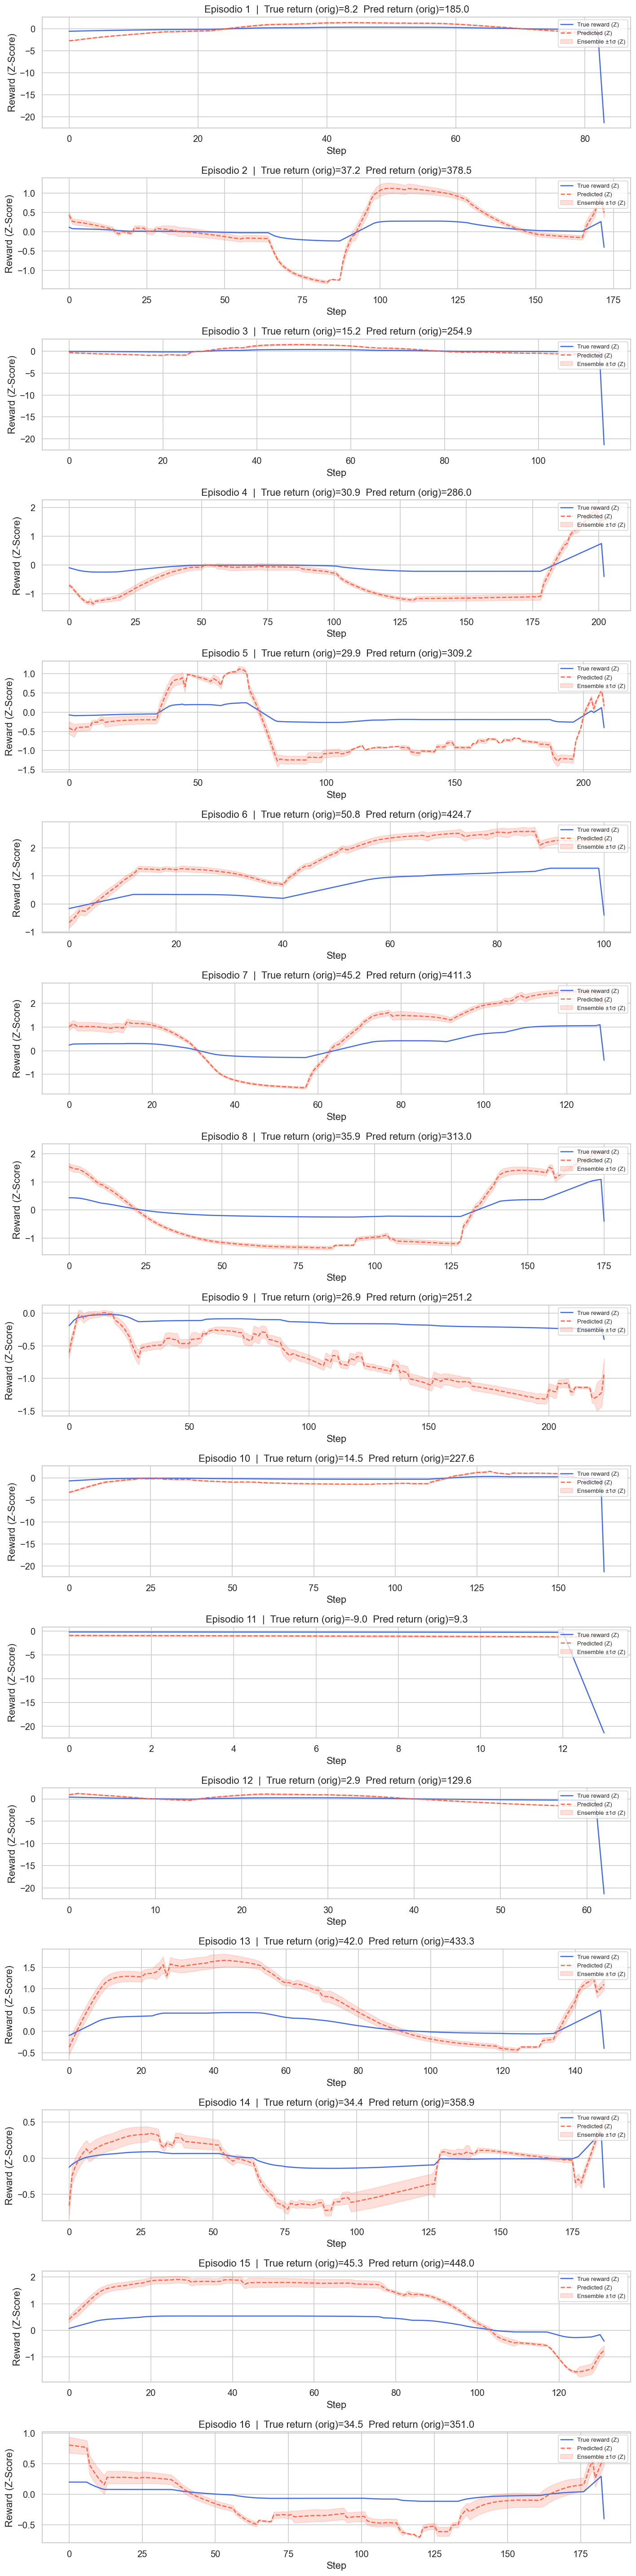

In [16]:
# ── 1. Calcolo Statistiche GLOBALI (su tutti i timestep disponibili) ─────────
all_true = np.concatenate([t["true_rewards"] for t in trajs])
all_pred = np.concatenate([t["pred_rewards_mean"] for t in trajs])

true_mean, true_std = all_true.mean(), all_true.std() + 1e-8
pred_mean, pred_std = all_pred.mean(), all_pred.std() + 1e-8

# ── 9. Reward curve per traiettoria (Z-Scored) ───────────────────────────────
N_SHOW = min(16, len(trajs))

fig, axes = plt.subplots(N_SHOW, 1, figsize=(12, 3 * N_SHOW), sharex=False)
if N_SHOW == 1:
    axes = [axes]

for i, (traj, ax) in enumerate(zip(trajs[:N_SHOW], axes)):
    t = np.arange(len(traj["true_rewards"]))

    # ── 2. Standardizzazione delle curve dell'episodio ──
    true_z = (traj["true_rewards"] - true_mean) / true_std
    pred_z = (traj["pred_rewards_mean"] - pred_mean) / pred_std

    # La deviazione standard dell'ensemble viene SOLO scalata, non traslata
    uncert_z = traj["pred_rewards_std"] / pred_std

    # Plotting
    ax.plot(t, true_z,      label="True reward (Z)",      color="royalblue", lw=1.5)
    ax.plot(t, pred_z, label="Predicted (Z)", color="tomato",    lw=1.5, ls="--")
    ax.fill_between(t,
                    pred_z - uncert_z,
                    pred_z + uncert_z,
                    alpha=0.2, color="tomato", label="Ensemble ±1σ (Z)")

    # Manteniamo i valori originali nel titolo per riferimento assoluto
    tr_orig  = traj["true_rewards"].sum()
    pr_orig  = traj["pred_rewards_mean"].sum()

    ax.set_title(f"Episodio {i+1}  |  True return (orig)={tr_orig:.1f}  Pred return (orig)={pr_orig:.1f}")
    ax.set_xlabel("Step"); ax.set_ylabel("Reward (Z-Score)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_trajectories_zscore.png", dpi=150); plt.show()

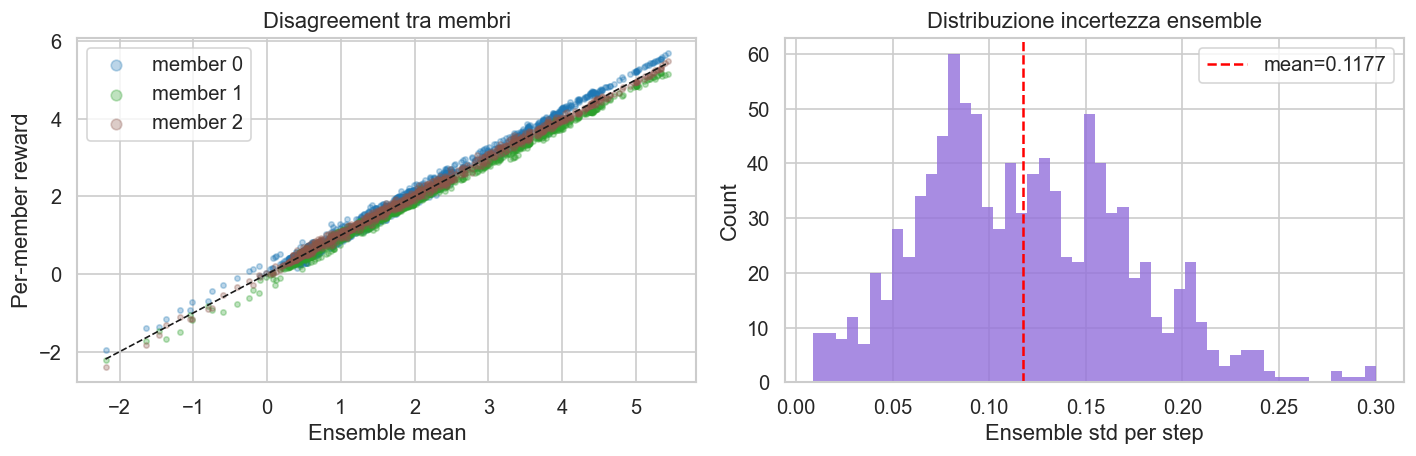

In [17]:
# ── 10. Ensemble member disagreement (step) ───────────────────────────────
# Confronta i singoli membri dell'ensemble su un campione di step
SAMPLE_N = min(1000, len(all_true))
idx_s = np.random.choice(len(all_true), size=SAMPLE_N, replace=False)

# Per ogni campione rigenera le predizioni per-membro
flat_obs  = np.concatenate([t["obs"]     for t in trajs])[idx_s]
flat_acts = np.concatenate([t["actions"] for t in trajs])[idx_s]

with torch.no_grad():
    obs_t  = torch.tensor(flat_obs,  dtype=torch.float32)
    acts_t = torch.tensor(flat_acts, dtype=torch.float32)
    per_member = np.stack([m(obs_t, acts_t).numpy() for m in members], axis=0)  # (n, S)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter di ogni membro contro la media ensemble
member_mean = per_member.mean(axis=0)
colors = plt.cm.tab10(np.linspace(0, 0.5, len(members)))
for i, (row, c) in enumerate(zip(per_member, colors)):
    axes[0].scatter(member_mean, row, s=10, alpha=0.3, color=c, label=f"member {i}")
diag_m = [member_mean.min(), member_mean.max()]
axes[0].plot(diag_m, diag_m, "k--", lw=1)
axes[0].set_xlabel("Ensemble mean"); axes[0].set_ylabel("Per-member reward")
axes[0].set_title("Disagreement tra membri"); axes[0].legend(markerscale=2)

# Istogramma dello std per step
step_stds = per_member.std(axis=0)
axes[1].hist(step_stds, bins=50, color="mediumpurple", edgecolor="none", alpha=0.8)
axes[1].axvline(step_stds.mean(), color="red", ls="--", label=f"mean={step_stds.mean():.4f}")
axes[1].set_xlabel("Ensemble std per step"); axes[1].set_ylabel("Count")
axes[1].set_title("Distribuzione incertezza ensemble"); axes[1].legend()

plt.tight_layout(); plt.savefig(RUN_DIR / "plot_ensemble.png", dpi=150); plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Membri molto allineati → ensemble poco diversificato → incertezza sottostimata
# Std concentrata vicino a 0 → la maggior parte degli stati è in-distribution
# Coda lunga degli std → stati OOD che il RM gestisce con alta varianza


In [18]:
# ── 11. Summary table ──────────────────────────────────────────────────────
print("\n" + "="*55)
print("  REWARD MODEL DIAGNOSTIC SUMMARY")
print("="*55)
print(f"  Run dir:            {RUN_DIR.name}")
print(f"  Ensemble members:   {ckpt['n_members']}")
print(f"  Episodes analyzed:  {len(trajs)}")
print(f"  Steps analyzed:     {len(all_true)}")
print("-"*55)
print(f"  Step-level MAE:         {all_abserr.mean():.4f}")
print(f"  Step-level RMSE:        {np.sqrt((all_err**2).mean()):.4f}")
print(f"  Step-level bias:        {all_err.mean():+.4f}  ({'RM ottimista' if all_err.mean()>0 else 'RM pessimista'})")
print(f"  Step-level Pearson r:   {p_step:.3f}")
print(f"  Episode Pearson r:      {p_ep:.3f}")
print(f"  Episode Spearman ρ:     {s_ep:.3f}")
print(f"  Reward gap (mean):      {ep_gap.mean():+.2f}")
print(f"  Exploitation index:     {exploitation_index.mean():.3f}  ({'⚠ ALTO' if exploitation_index.mean()>1.5 else 'OK'})")
print(f"  Mean ensemble std:      {all_std.mean():.4f}")
print("="*55)

# ── Interpretazione finale ───────────────────────────────────────────────────
# Step Pearson > 0.85  → RM apprende bene a livello di singolo step
# Episode Pearson > 0.85 → RM apprende bene a livello di episodio
# Bias > 0             → RM ottimista → potenziale reward hacking
# Exploitation index > 1.5 → segnale forte di reward hacking



  REWARD MODEL DIAGNOSTIC SUMMARY
  Run dir:            2026-05-09_23-58-21_PPO_seg_1_reg_ON
  Ensemble members:   3
  Episodes analyzed:  17
  Steps analyzed:     2495
-------------------------------------------------------
  Step-level MAE:         1.8898
  Step-level RMSE:        2.2459
  Step-level bias:        +1.8733  (RM ottimista)
  Step-level Pearson r:   0.321
  Episode Pearson r:      0.969
  Episode Spearman ρ:     0.961
  Reward gap (mean):      +274.93
  Exploitation index:     17.206  (⚠ ALTO)
  Mean ensemble std:      0.1177


## Grafici aggiuntivi — diagnosi approfondita

/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_18926/610706179.py:79: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/4x/p3g0s81s02gfy2x869p4qg740000gn/T/ipykernel_18926/610706179.py:80: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.savefig(RUN_DIR / "plot_logit_distribution.png", dpi=150)
/Users/andreazhang/Documents/fis/sumo-human-feedback-rl/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


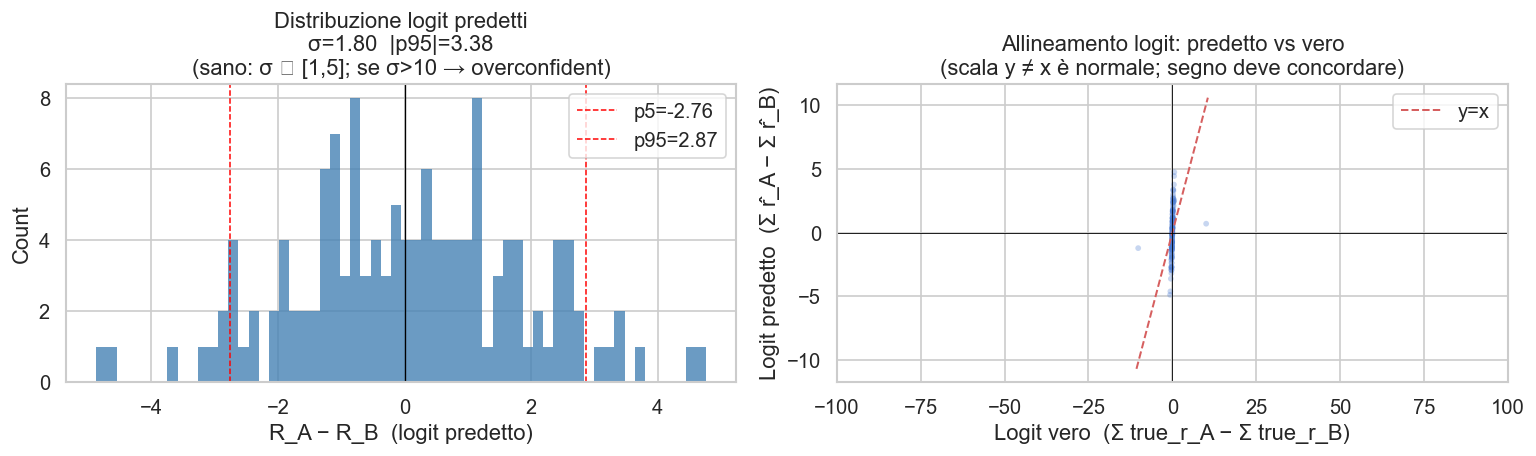

In [19]:
# ── A. Distribuzione dei logit di preferenza (val set) ────────────────────
# I logit = R_A - R_B sono la quantità che il RM produce al momento della
# comparazione. Se |logit| è molto grande il modello è overconfident:
# riesce ad azzerare la loss BCE spingendo la differenza di return verso ±∞.
# Label smoothing (ε=0.1) dovrebbe contenere questo fenomeno.
#
# Questo grafico richiede solo il reward model e i debug data già caricati:
# ricostruiamo coppie sintetiche campionando casualmente le traiettorie a
# disposizione, esattamente come fa RandomFragmenter durante il training.

RNG_LOGIT = np.random.default_rng(42)
N_PAIRS   = min(500, len(trajs) * (len(trajs) - 1) // 2)

flat_obs_all  = np.concatenate([t["obs"]     for t in trajs])
flat_acts_all = np.concatenate([t["actions"] for t in trajs])
flat_true_all = np.concatenate([t["true_rewards"] for t in trajs])

# Lunghezze episodio per costruire segmenti
ep_lengths = [len(t["true_rewards"]) for t in trajs]
ep_starts  = np.cumsum([0] + ep_lengths[:-1])

def sample_fragment_return(ep_idx, frag_len=1):
    """Campiona un frammento casuale dall'episodio ep_idx, ritorna (r_pred, r_true)."""
    start = ep_starts[ep_idx]
    L     = ep_lengths[ep_idx]
    if L < frag_len:
        return None
    t0 = RNG_LOGIT.integers(0, L - frag_len + 1)
    sl = slice(start + t0, start + t0 + frag_len)
    obs_f  = torch.tensor(flat_obs_all[sl],  dtype=torch.float32)
    acts_f = torch.tensor(flat_acts_all[sl], dtype=torch.float32)
    with torch.no_grad():
        r_pred = sum(m(obs_f, acts_f).sum().item() for m in members) / len(members)
    r_true = flat_true_all[sl].sum()
    return r_pred, r_true

logits_pred, logits_true = [], []
ep_indices = np.arange(len(trajs))
for _ in range(N_PAIRS):
    i, j = RNG_LOGIT.choice(ep_indices, size=2, replace=False)
    res_i = sample_fragment_return(i)
    res_j = sample_fragment_return(j)
    if res_i and res_j:
        logits_pred.append(res_i[0] - res_j[0])
        logits_true.append(res_i[1] - res_j[1])

logits_pred = np.array(logits_pred)
logits_true = np.array(logits_true)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuzione dei logit predetti
axes[0].hist(logits_pred, bins=60, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(0, color="black", lw=0.8)
for q in [5, 95]:
    v = np.percentile(logits_pred, q)
    axes[0].axvline(v, color="red", ls="--", lw=0.9, label=f"p{q}={v:.2f}")
axes[0].set_xlabel("R_A − R_B  (logit predetto)")
axes[0].set_ylabel("Count")
axes[0].set_title(
    f"Distribuzione logit predetti\n"
    f"σ={logits_pred.std():.2f}  |p95|={np.percentile(np.abs(logits_pred),95):.2f}\n"
    f"(sano: σ ∈ [1,5]; se σ>10 → overconfident)"
)
axes[0].legend()

# Confronto logit predetti vs logit veri (allineamento)
axes[1].scatter(logits_true, logits_pred, alpha=0.3, s=12, edgecolors="none")
lim_l = (min(logits_true.min(), logits_pred.min()) * 1.05,
         max(logits_true.max(), logits_pred.max()) * 1.05)
axes[1].plot(lim_l, lim_l, "r--", lw=1.2, label="y=x")
axes[1].axhline(0, color="black", lw=0.5); axes[1].axvline(0, color="black", lw=0.5)
axes[1].set_xlabel("Logit vero  (Σ true_r_A − Σ true_r_B)")
axes[1].set_xlim(-100,100)
axes[1].set_ylabel("Logit predetto  (Σ r̂_A − Σ r̂_B)")
axes[1].set_title("Allineamento logit: predetto vs vero\n(scala y ≠ x è normale; segno deve concordare)")
axes[1].legend()

plt.tight_layout()
plt.savefig(RUN_DIR / "plot_logit_distribution.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# σ logit predetto >> σ logit vero → RM ha gonfiato la scala dei reward
#   → conferma che mean regularisation o label smoothing non bastano a contenere
# Segno concorde (punti nel quadrante I e III) → il RM ordina correttamente le coppie
# Punti nel quadrante II/IV → comparazioni invertite → fonte di reward hacking

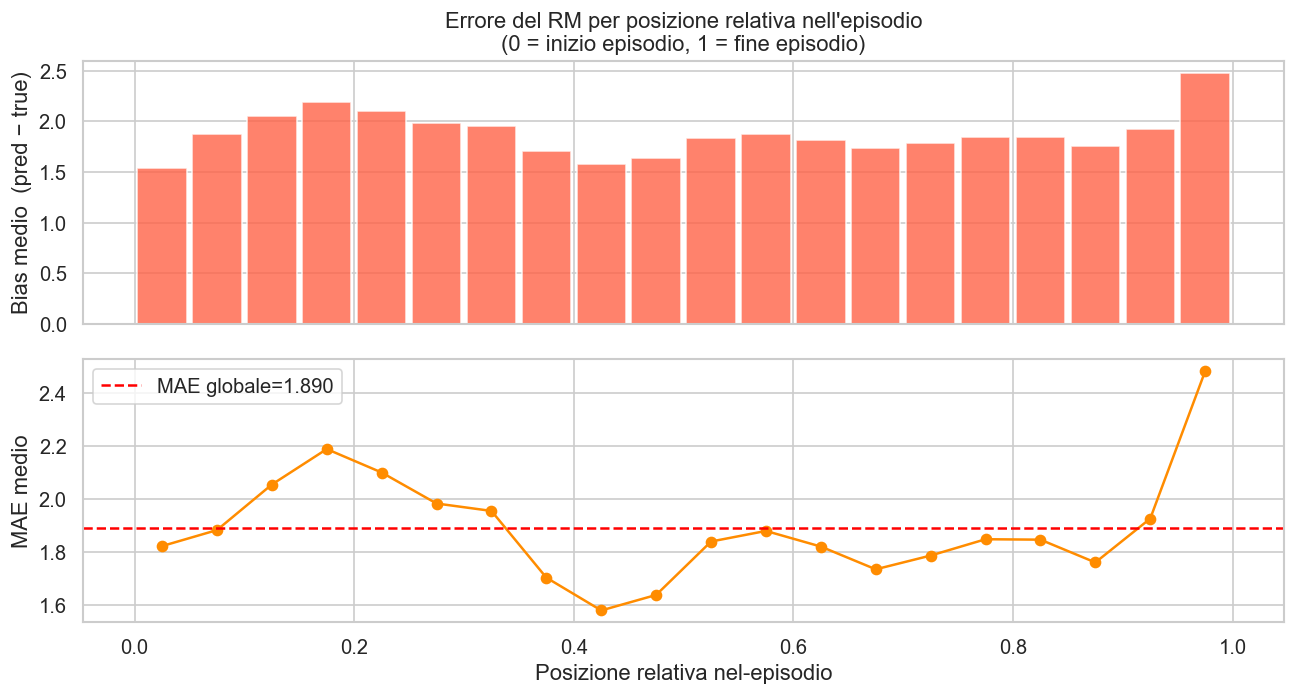

In [18]:
# ── B. Errore per posizione relativa nell'episodio ────────────────────────
# Domanda: il RM sbaglia di più all'inizio o alla fine di un episodio?
# Se l'errore cresce verso la fine → la policy ha imparato a "rallentare"
# i primi step (true reward bassa) e "accelerare" gli ultimi dove il RM
# è meno calibrato → segnale di reward hacking temporalmente strutturato.
#
# step_pos = t / T_ep  → normalizza ogni step in [0, 1]
# Binniamo le posizioni e plottiamo bias medio + MAE per bin.

N_BINS_POS = 20

all_pos  = np.concatenate([
    np.linspace(0, 1, len(t["true_rewards"]), endpoint=False)
    for t in trajs
])
all_err_b = np.concatenate([
    t["pred_rewards_mean"] - t["true_rewards"]
    for t in trajs
])
all_abserr_b = np.abs(all_err_b)

bin_edges = np.linspace(0, 1, N_BINS_POS + 1)
bin_ctrs  = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bias_per_bin   = []
mae_per_bin    = []
count_per_bin  = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (all_pos >= lo) & (all_pos < hi)
    if mask.sum() == 0:
        bias_per_bin.append(np.nan); mae_per_bin.append(np.nan); count_per_bin.append(0)
        continue
    bias_per_bin.append(all_err_b[mask].mean())
    mae_per_bin.append(all_abserr_b[mask].mean())
    count_per_bin.append(mask.sum())

bias_per_bin  = np.array(bias_per_bin)
mae_per_bin   = np.array(mae_per_bin)
count_per_bin = np.array(count_per_bin)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# Bias (signed error) per posizione
axes[0].bar(bin_ctrs, bias_per_bin, width=0.9/N_BINS_POS,
            color=np.where(bias_per_bin > 0, "tomato", "steelblue"), alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("Bias medio  (pred − true)")
axes[0].set_title(
    "Errore del RM per posizione relativa nell'episodio\n"
    "(0 = inizio episodio, 1 = fine episodio)"
)

# MAE per posizione
axes[1].plot(bin_ctrs, mae_per_bin, "o-", color="darkorange", lw=1.5)
axes[1].axhline(all_abserr_b.mean(), color="red", ls="--",
                label=f"MAE globale={all_abserr_b.mean():.3f}")
axes[1].set_ylabel("MAE medio")
axes[1].set_xlabel("Posizione relativa nel-episodio")
axes[1].legend()

plt.tight_layout()
plt.savefig(RUN_DIR / "plot_error_by_ep_position.png", dpi=150)
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# Bias piatto → errore casuale, non strutturato temporalmente → OK
# Bias crescente verso fine ep → RM sovrastima di più su stati "exploit" tardivi
# MAE crescente → il RM diventa meno preciso man mano che l'episodio avanza
#   (possibile: stati visitati raramente nella seconda metà = OOD per il RM)

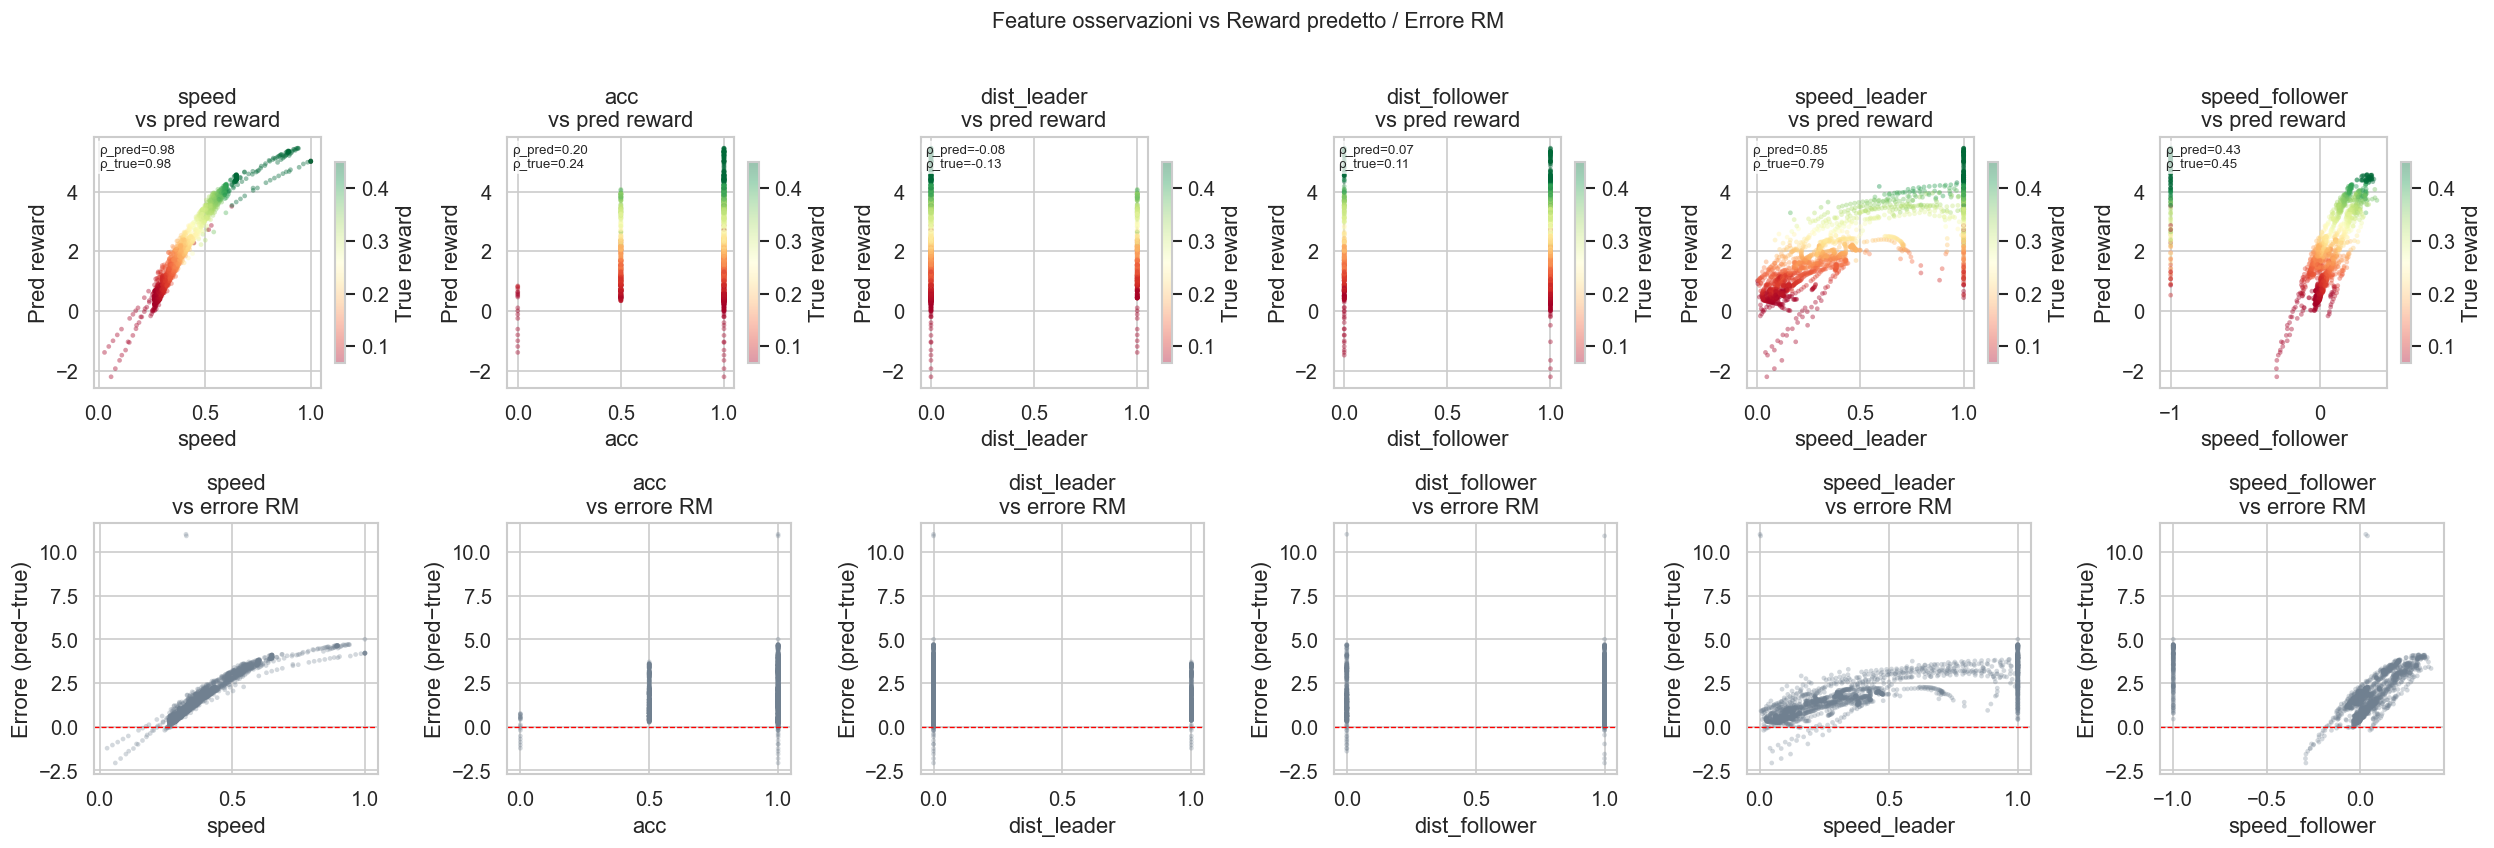

In [19]:
# ── C. Feature delle osservazioni vs reward predetto ─────────────────────
# Domanda: il RM ha imparato correlazioni sensate tra feature SUMO e reward?
# Es. velocità alta → reward alta (legge fisica ovvia nell'env).
# Se la correlazione è invertita o assente → il RM si basa su feature spurie.
#
# obs_dim=16: i nomi esatti dipendono dall'env, ma le prime feature
# tipiche di sumo-rl-ego continuous sono elencate sotto. Adatta se necessario.
# Se non conosci l'ordine, usa solo gli indici e interpreta empiricamente.

OBS_FEATURE_NAMES = [
    "speed",           # 0  — velocità ego normalizzata
    "acc",             # 1  — accelerazione
    "dist_leader",     # 2  — distanza dal veicolo davanti
    "dist_follower",   # 3  — distanza dal veicolo dietro
    "speed_leader",    # 4
    "speed_follower",  # 5
    "dist_interx",     # 6  — distanza dall'incrocio
    "tls_phase",       # 7  — fase semaforo (0=red,1=green,...)
    "f8", "f9", "f10", "f11", "f12", "f13", "f14", "f15",
][:ckpt["obs_dim"]]    # taglia automaticamente se obs_dim < 16

flat_obs_c  = np.concatenate([t["obs"]               for t in trajs])
flat_pred_c = np.concatenate([t["pred_rewards_mean"]  for t in trajs])
flat_true_c = np.concatenate([t["true_rewards"]       for t in trajs])

# Selezioniamo le prime N_FEAT feature più interessanti da plottare
N_FEAT = min(6, ckpt["obs_dim"])
feat_indices = list(range(N_FEAT))

fig, axes = plt.subplots(2, N_FEAT, figsize=(3.5 * N_FEAT, 7))
if N_FEAT == 1:
    axes = axes.reshape(2, 1)

# Campiona per leggibilità
idx_c = np.random.default_rng(0).choice(len(flat_obs_c), size=min(2000, len(flat_obs_c)), replace=False)

for col, fi in enumerate(feat_indices):
    feat_vals = flat_obs_c[idx_c, fi]
    fname = OBS_FEATURE_NAMES[fi] if fi < len(OBS_FEATURE_NAMES) else f"f{fi}"

    # Riga 0: feature vs pred reward, colorato per true reward
    sc0 = axes[0, col].scatter(
        feat_vals, flat_pred_c[idx_c],
        c=flat_true_c[idx_c], cmap="RdYlGn", alpha=0.4, s=8, edgecolors="none",
        vmin=np.percentile(flat_true_c, 5), vmax=np.percentile(flat_true_c, 95)
    )
    axes[0, col].set_xlabel(fname); axes[0, col].set_ylabel("Pred reward")
    axes[0, col].set_title(f"{fname}\nvs pred reward")
    plt.colorbar(sc0, ax=axes[0, col], label="True reward", shrink=0.8)

    # Riga 1: feature vs errore (pred - true)
    axes[1, col].scatter(
        feat_vals, (flat_pred_c - flat_true_c)[idx_c],
        alpha=0.3, s=8, edgecolors="none", color="slategray"
    )
    axes[1, col].axhline(0, color="red", lw=0.8, ls="--")
    axes[1, col].set_xlabel(fname); axes[1, col].set_ylabel("Errore (pred−true)")
    axes[1, col].set_title(f"{fname}\nvs errore RM")

    # Spearman feature→pred e feature→true
    sp_pred, _ = spearmanr(flat_obs_c[:, fi], flat_pred_c)
    sp_true, _ = spearmanr(flat_obs_c[:, fi], flat_true_c)
    axes[0, col].text(0.02, 0.97, f"ρ_pred={sp_pred:.2f}\nρ_true={sp_true:.2f}",
                      transform=axes[0, col].transAxes, va="top", fontsize=8,
                      bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

plt.suptitle("Feature osservazioni vs Reward predetto / Errore RM", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(RUN_DIR / "plot_feature_vs_reward.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Interpretazione ──────────────────────────────────────────────────────────
# ρ_pred ≈ ρ_true su una feature → il RM ha imparato quella feature correttamente
# ρ_pred >> ρ_true → il RM usa quella feature più di quanto dovrebbe (spurious)
# ρ_pred ≈ 0 ma ρ_true > 0 → il RM ignora una feature informativa → underfitting locale
# Errore strutturato per feature (pattern visibile) → bias sistematico del RM su quella dimensione

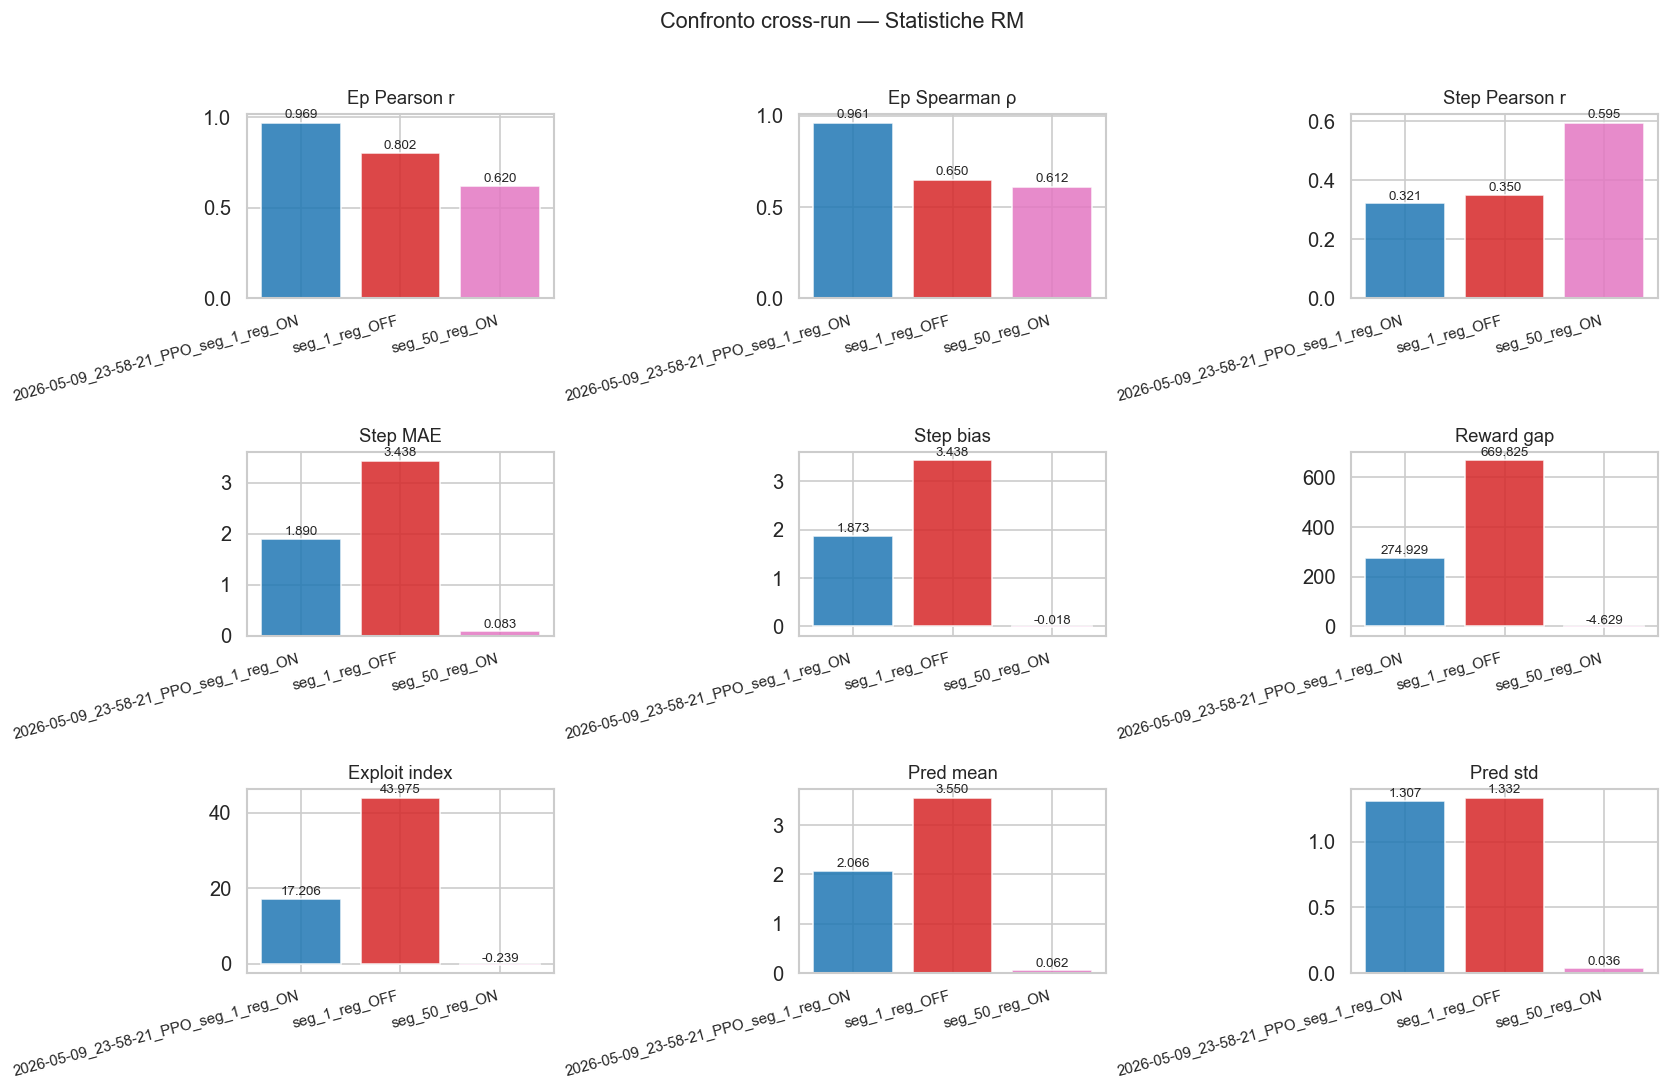


Metrica              2026-05-09_23-58-21_PPO_seg_1_reg_ON       seg_1_reg_OFF       seg_50_reg_ON
--------------------------------------------------------------------------------
Ep Pearson r                      0.9693              0.8017              0.6200
Ep Spearman ρ                     0.9608              0.6503              0.6121
Step Pearson r                    0.3215              0.3501              0.5948
Step MAE                          1.8898              3.4380              0.0830
Step bias                         1.8733              3.4379             -0.0184
Reward gap                      274.9285            669.8250             -4.6286
Exploit index                    17.2064             43.9752             -0.2386
Pred mean                         2.0656              3.5500              0.0621
Pred std                          1.3069              1.3320              0.0362


In [22]:
# ── D. Confronto cross-run (ablation: reg_ON vs reg_OFF) ─────────────────
# Carica più run_dir con configurazioni diverse e sovrappone le statistiche.
# Utile per comparare mean regularisation ON vs OFF, o diversi valori di ε.
#
# Modifica RUN_CONFIGS con i tuoi run effettivi.

RUN_CONFIGS = {
    # "label": Path("../outputs/train/<run_dir>")
    # Esempio con il run corrente come unico entry:
    RUN_DIR.name: RUN_DIR,
    # Decommentare e aggiungere altri run:
    "seg_1_reg_OFF": Path("../outputs/train/2026-05-10_00-18-54_PPO_seg_1_reg_OFF"),
    "seg_50_reg_ON": Path("../outputs/train/2026-05-10_05-13-47_PPO_seg_50_reg_ON"),

}

# Per ogni run calcoliamo le stesse statistiche del summary
results = {}
for label, rdir in RUN_CONFIGS.items():
    dbg_path = rdir / "debug_data.pkl"
    rm_path  = rdir / "reward_model.pt"
    if not dbg_path.exists() or not rm_path.exists():
        print(f"[SKIP] {label}: file mancanti in {rdir}")
        continue
    with open(dbg_path, "rb") as f:
        d = pickle.load(f)
    ep_tr = np.array(d["episode_true_returns"])
    ep_pr = np.array(d["episode_pred_returns"])
    at    = np.concatenate([t["true_rewards"]      for t in d["trajectories"]])
    ap    = np.concatenate([t["pred_rewards_mean"] for t in d["trajectories"]])
    ae    = ap - at

    p_ep_r, _ = pearsonr(ep_tr, ep_pr)
    s_ep_r, _ = spearmanr(ep_tr, ep_pr)
    p_st_r, _ = pearsonr(at, ap)
    gap        = (ep_pr - ep_tr).mean()
    expl_idx   = gap / (ep_tr.std() + 1e-8)

    results[label] = {
        "ep_pearson":   p_ep_r,
        "ep_spearman":  s_ep_r,
        "step_pearson": p_st_r,
        "step_mae":     np.abs(ae).mean(),
        "step_bias":    ae.mean(),
        "reward_gap":   gap,
        "expl_index":   expl_idx,
        "pred_mean":    ap.mean(),
        "pred_std":     ap.std(),
        "n_episodes":   len(ep_tr),
    }

if not results:
    print("Nessun run valido trovato. Aggiungere path reali in RUN_CONFIGS.")
else:
    labels = list(results.keys())
    metrics = ["ep_pearson", "ep_spearman", "step_pearson", "step_mae",
               "step_bias", "reward_gap", "expl_index", "pred_mean", "pred_std"]
    metric_labels = ["Ep Pearson r", "Ep Spearman ρ", "Step Pearson r",
                     "Step MAE", "Step bias", "Reward gap", "Exploit index",
                     "Pred mean", "Pred std"]

    # Bar chart per ogni metrica
    fig, axes = plt.subplots(3, 3, figsize=(14, 9))
    axes = axes.flatten()

    x = np.arange(len(labels))
    for ai, (m, ml) in enumerate(zip(metrics, metric_labels)):
        vals = [results[l][m] for l in labels]
        bars = axes[ai].bar(x, vals, color=plt.cm.tab10(np.linspace(0, 0.6, len(labels))), alpha=0.85)
        axes[ai].set_xticks(x); axes[ai].set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
        axes[ai].set_title(ml, fontsize=11)
        for bar, v in zip(bars, vals):
            axes[ai].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                          f"{v:.3f}", ha="center", va="bottom", fontsize=8)

    plt.suptitle("Confronto cross-run — Statistiche RM", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(RUN_DIR / "plot_crossrun_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Tabella testuale
    print(f"\n{'Metrica':<20}", "  ".join(f"{l:>18}" for l in labels))
    print("-" * (20 + 20 * len(labels)))
    for m, ml in zip(metrics, metric_labels):
        row = "  ".join(f"{results[l][m]:>18.4f}" for l in labels)
        print(f"{ml:<20}  {row}")

# ── Interpretazione ──────────────────────────────────────────────────────────
# reg_ON vs reg_OFF: atteso pred_mean più basso e bias più basso con reg attiva
# Se ep_pearson/spearman sono simili → la regularisation non peggiora il ranking
# Se expl_index scende con reg_ON → la regularisation riduce il rischio di hacking